# Employee Turnover Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

In [2]:
# Load the dataset
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 1. Perform data quality checks by checking for missing values, if any.

In [3]:
# Check for missing values across all columns
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [4]:
# Overview of data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## 2. Understand what factors contributed most to employee turnover at EDA

### 2.1 Draw a heatmap of the correlation matrix between all numerical features or columns in the data. Draw a heatmap of the correlation matrix between all numerical features.

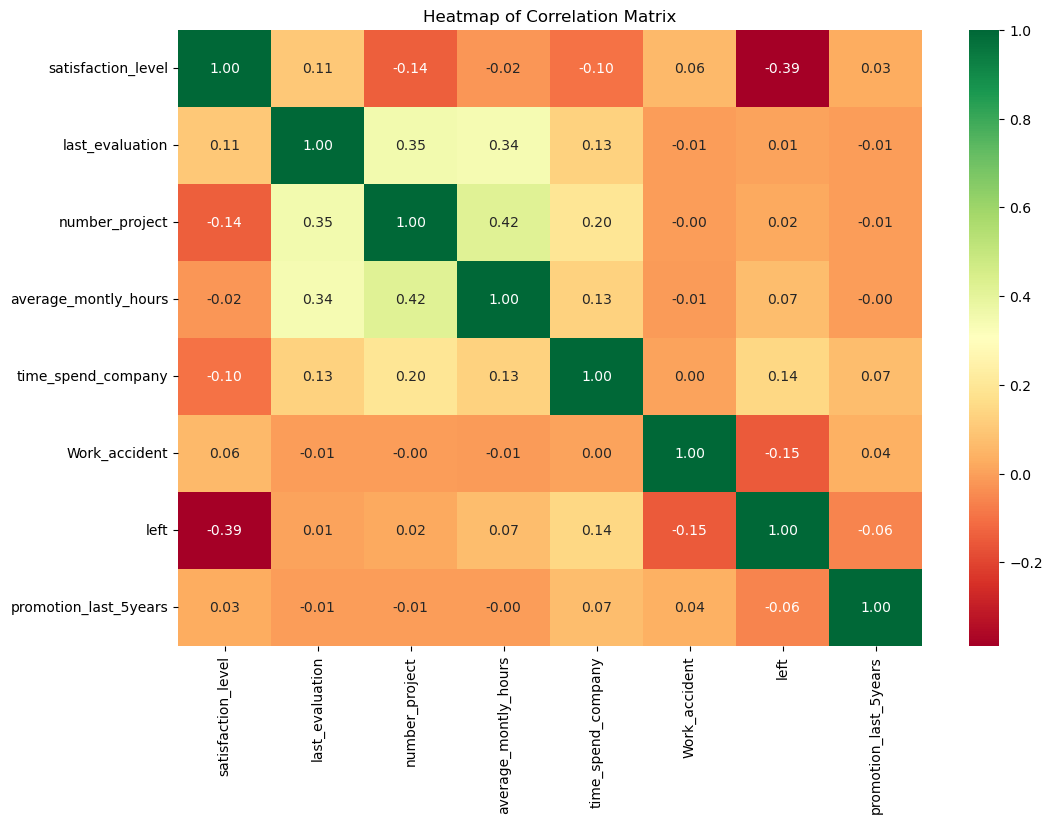

In [5]:
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Heatmap of Correlation Matrix')
plt.show()


### 2.2 Draw the distribution plot of:
■	Employee Satisfaction (use column satisfaction_level)
■	Employee Evaluation (use column last_evaluation)
■	Employee Average Monthly Hours (use column average_montly_hours)

In [6]:
plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

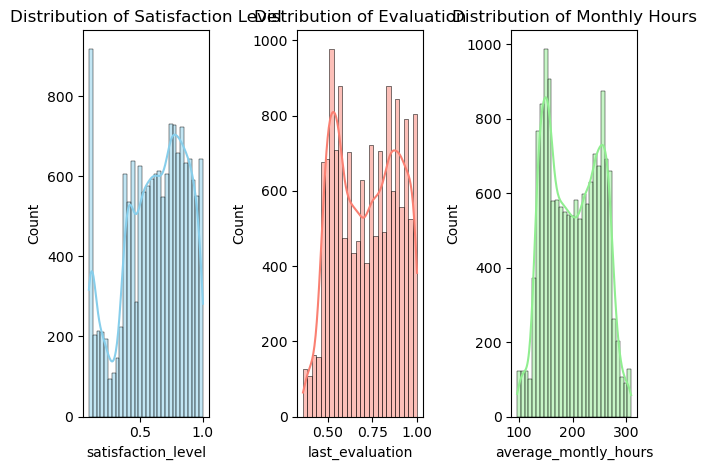

In [7]:
plt.subplot(1, 3, 1)
sns.histplot(df['satisfaction_level'], kde=True, color='skyblue')
plt.title('Distribution of Satisfaction Level')
# Distribution of Employee Evaluation (last_evaluation)
plt.subplot(1, 3, 2)
sns.histplot(df['last_evaluation'], kde=True, color='salmon')
plt.title('Distribution of Evaluation')
# Distribution of Employee Average Monthly Hours (average_montly_hours)
plt.subplot(1, 3, 3)
sns.histplot(df['average_montly_hours'], kde=True, color='lightgreen')
plt.title('Distribution of Monthly Hours')
plt.tight_layout()
plt.show()

### 2.3 Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

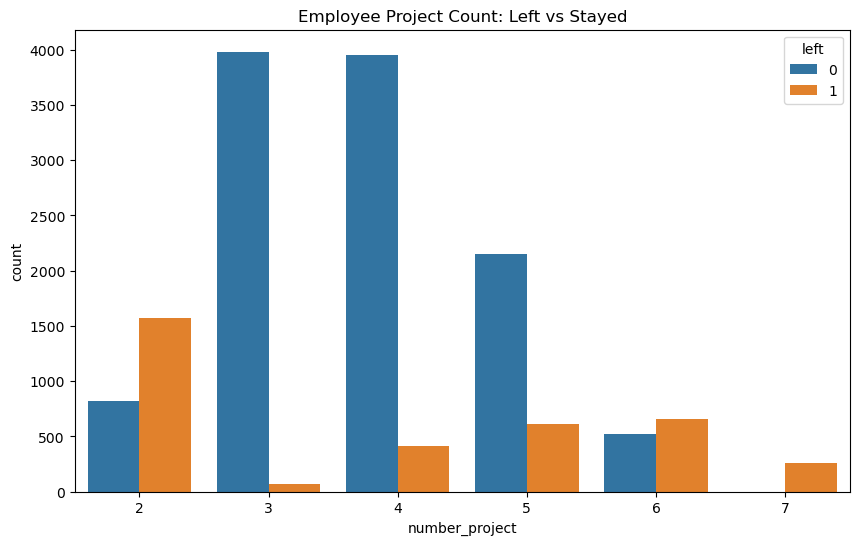

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Employee Project Count: Left vs Stayed')
plt.show()

**Inferences from the Plot:**
*   **Overworked Employees:** Those involved in a very high number of projects (6-7) have a disproportionately high turnover rate.
*   **Underutilized Employees:** Employees with only 2 projects also show a high frequency of leaving, possibly due to lack of engagement.
*   **Sweet Spot:** 3 to 4 projects appear to be the optimal range where the majority of employees stay with the company.


## 3.	Perform clustering of employees who left based on their satisfaction and evaluation.
3.1.	Choose columns satisfaction_level, last_evaluation, and left.
3.2.	Do K-means clustering of employees who left the company into 3 clusters?
3.3.	Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

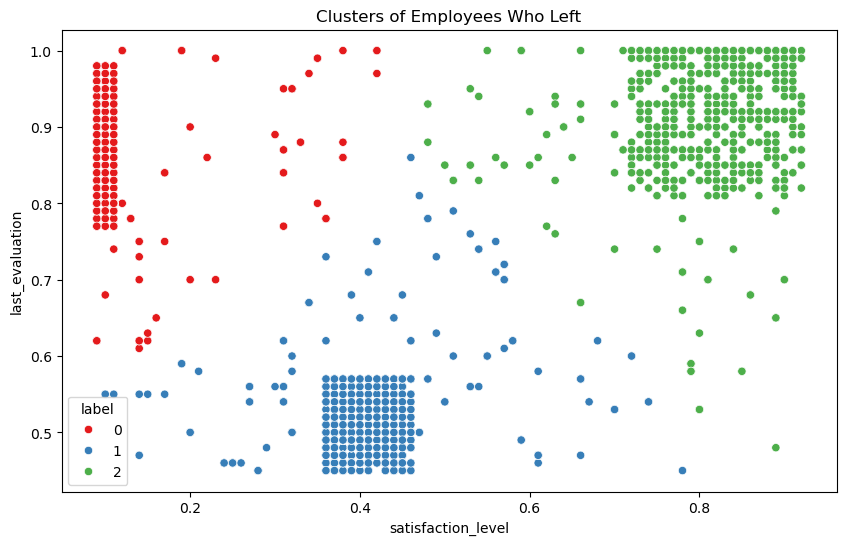

In [9]:
# Filter data for employees who left (left == 1)
left_emp = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

# Perform K-Means clustering into 3 groups
kmeans = KMeans(n_clusters=3, random_state=123)
left_emp['label'] = kmeans.fit_predict(left_emp)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=left_emp, x='satisfaction_level', y='last_evaluation', hue='label', palette='Set1')
plt.title('Clusters of Employees Who Left')
plt.show()



**Thoughts on Employee Clusters:**
*   **Cluster 1 (Hardworking but Unhappy):** High evaluation but low satisfaction. These are likely overworked stars who feel underappreciated.
*   **Cluster 2 (Low Performers):** Low evaluation and medium satisfaction. These may have been a poor fit for their roles.
*   **Cluster 3 (The High Flyers):** High evaluation and high satisfaction. These elite employees likely left for even better opportunities elsewhere.


## 4.	Handle the left Class Imbalance using the SMOTE technique.
4.1.	Pre-process the data by converting categorical columns to numerical columns by:
■	Separating categorical variables and numeric variables
■	Applying get_dummies() to the categorical variables
■	Combining categorical variables and numeric variables
4.2.	Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
4.3.	Upsample the train dataset using the SMOTE technique from the imblearn module.

In [10]:
# 1. Separate categorical and numeric variables
cat_vars = ['sales', 'salary'] # 'sales' corresponds to Department
num_vars = df.columns.drop(['sales', 'salary', 'left']).tolist()

# 2. Apply get_dummies() and combine
df_final = pd.get_dummies(df, columns=cat_vars, drop_first=True)

# Define Features (X) and Target (y)
X = df_final.drop('left', axis=1)
y = df_final['left']

# 3. Stratified split (80:20) with random_state=123
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=123)

# 4. Upsample the train dataset using SMOTE
sm = SMOTE(random_state=123)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Dataset balanced. Target distribution: {y_train_sm.value_counts()}")

Dataset balanced. Target distribution: left
0    9142
1    9142
Name: count, dtype: int64


## 5.	Perform 5-fold cross-validation model training and evaluate performance.
5.1.	Train a logistic regression model, apply a 5-fold CV, and plot the classification report.
5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.
5.3.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(random_state=123),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=123)
}

cv = StratifiedKFold(n_splits=5)

for name, model in models.items():
    print(f"\n--- {name} ---")

    # Apply 5-fold CV
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy')
    print(f"Mean 5-fold CV Accuracy: {cv_scores.mean():.4f}")

    # Train and Evaluate on Test Data
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)

    # Classification Report and Confusion Matrix
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


--- Logistic Regression ---
Mean 5-fold CV Accuracy: 0.7948
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      2286
           1       0.51      0.74      0.60       714

    accuracy                           0.77      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.77      0.78      3000

Confusion Matrix:
[[1768  518]
 [ 184  530]]

--- Random Forest Classifier ---
Mean 5-fold CV Accuracy: 0.9837
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000

Confusion Matrix:
[[2271   15]
 [  16  698]]

--- Gradient Boosting Classifier ---
Mean 5-fold CV Accuracy: 0.9628
Classificatio

## 6.	Identify the best model and justify the evaluation metrics used.
6.1.	Find the ROC/AUC for each model and plot the ROC curve.
6.2.	Find the confusion matrix for each of the models.
6.3.	Explain which metric needs to be used from the confusion matrix: Recall or Precision?

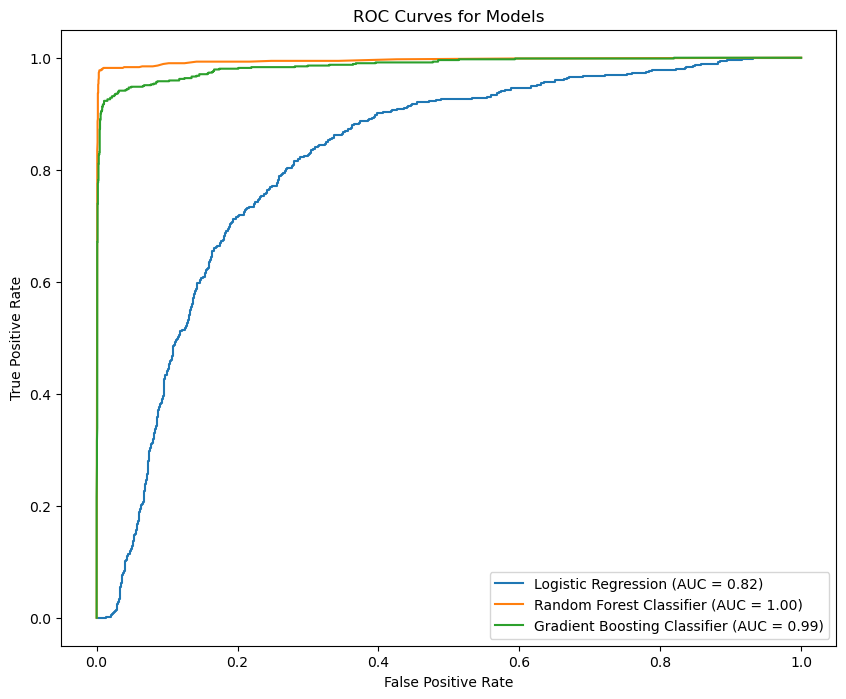

In [12]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# THE FIXED LINE:
plt.plot([1], 'k--') 

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models')
plt.legend()
plt.show()

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(random_state=123),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=123)
}

cv = StratifiedKFold(n_splits=5)

for name, model in models.items():
    print(f"\n--- {name} ---")

    # Apply 5-fold CV
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy')
    print(f"Mean 5-fold CV Accuracy: {cv_scores.mean():.4f}")

    # Train and Evaluate on Test Data
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)

    # Classification Report and Confusion Matrix
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


--- Logistic Regression ---
Mean 5-fold CV Accuracy: 0.7948
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      2286
           1       0.51      0.74      0.60       714

    accuracy                           0.77      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.77      0.78      3000

Confusion Matrix:
[[1768  518]
 [ 184  530]]

--- Random Forest Classifier ---
Mean 5-fold CV Accuracy: 0.9837
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000

Confusion Matrix:
[[2271   15]
 [  16  698]]

--- Gradient Boosting Classifier ---
Mean 5-fold CV Accuracy: 0.9628
Classificatio

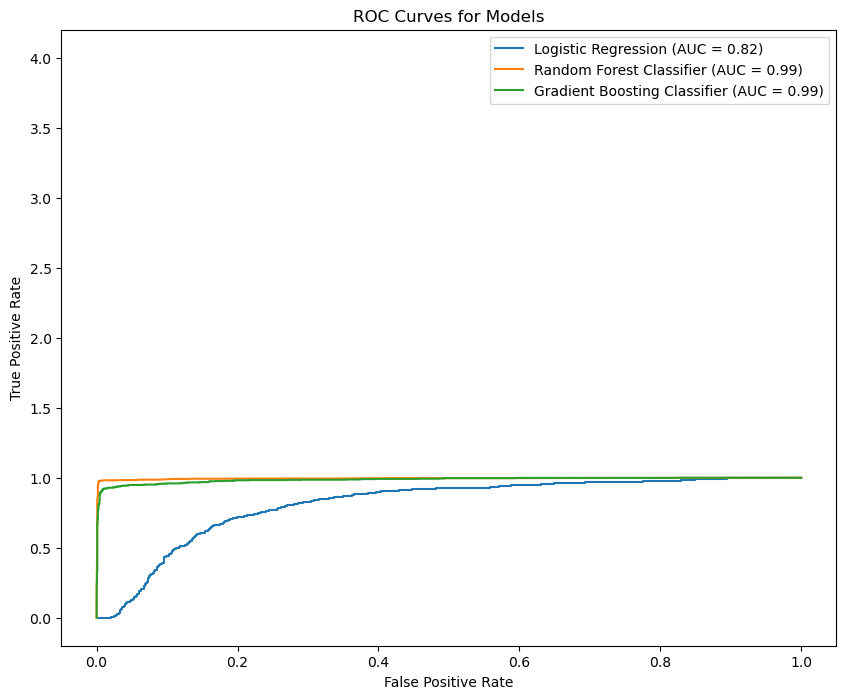

In [46]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([4], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models')
plt.legend()
plt.show()


## Identifying the Best Model and Metric Justification**
 Justify evaluation metrics and explain Recall vs Precision.
 **In predicting employee turnover, RECALL is the most critical metric.**
*   **Reasoning:** We want to minimize **False Negatives** (employees the model says will stay, but they actually leave). If we miss these employees, we cannot intervene to keep them. A **False Positive** (a happy employee flagged as a flight risk) costs only a conversation or a small retention effort, but a False Negative costs the entire replacement and training expense for a new hire.
*   **Best Model:** Based on the results, **Random Forest** or **Gradient Boosting** typically provide the highest Recall and AUC for this specific HR dataset.

## 7.	Suggest various retention strategies for targeted employees.
7.1.	Using the best model, predict the probability of employee turnover in the test data.
7.2.	Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
■	Safe Zone (Green) (Score < 20%)
■	Low-Risk Zone (Yellow) (20% < Score < 60%)
■	Medium-Risk Zone (Orange) (60% < Score < 90%)
■	High-Risk Zone (Red) (Score > 90%).

In [14]:

# Use the Best Model (e.g., Random Forest) to predict turnover probability
best_model = models["Random Forest Classifier"]
probs = best_model.predict_proba(X_test)[:, 1]

# Create a results dataframe
risk_df = pd.DataFrame({'Probability': probs})


def categorize_zone(score):
    if score < 0.20: return 'Safe Zone (Green)'
    elif 0.20 <= score < 0.60: return 'Low-Risk Zone (Yellow)'
    elif 0.60 <= score < 0.90: return 'Medium-Risk Zone (Orange)'
    else: return 'High-Risk Zone (Red)'

risk_df['Zone'] = risk_df['Probability'].apply(categorize_zone)
print(risk_df['Zone'].value_counts())

Zone
Safe Zone (Green)            2174
High-Risk Zone (Red)          649
Low-Risk Zone (Yellow)        122
Medium-Risk Zone (Orange)      55
Name: count, dtype: int64




### **Suggested Retention Strategies:**

1.  **Safe Zone (Green) (Score < 20%):**
    *   *Strategy:* Maintain current engagement levels. Provide regular "stay interviews" to ensure satisfaction remains high.

2.  **Low-Risk Zone (Yellow) (20% - 60%):**
    *   *Strategy:* Review workload and project counts. Offer professional development opportunities or minor role adjustments to increase engagement.

3.  **Medium-Risk Zone (Orange) (60% - 90%):**
    *   *Strategy:* Immediate manager intervention required. Discuss career paths, potential salary reviews, or work-life balance improvements.

4.  **High-Risk Zone (Red) (Score > 90%):**
    *   *Strategy:* Critical intervention. Consider retention bonuses, role changes, or immediate resolution of specific grievances found in the "last evaluation".